# **Notebook to make 3D crystalline particles and corresponding Bragg Coherent Diffraction pattern**

## *Authors: Dr. Ewen Bellec, Dr. Matteo Masto*


In [1]:
import numpy as np
import pylab as plt
import os
from pynx.scattering.fhkl import Fhkl_thread
from pynx.scattering.fthomson import f_thomson
import random
from numpy.fft import ifftshift, fftn, fftshift, ifftn

from Particle import *
from diffraction_noise_functions import *
from Global_utilities import *
from Object_utilities import *
from Plot_utilities import *
from PostProcessing import *

plt.rc('image', cmap='plasma')


In [2]:
NL = [40, 40, 40]  # size of the initial cube
element = 'Au'  # atomic element
path_potential = './Main_files/pot/'
print_mode = 'info_particle'

particle = Particle(NL=NL, element=element, path_potential=path_potential,
                    print_mode=print_mode)

# particle is the initial class, a large cubic particle.
# particle.u contains the position of each atoms

path_potential : ./Main_files/pot/
element : Au
NL : [40, 40, 40]
print_mode : info_particle
L : [163.2, 163.2, 163.2, 0.0]
a : 4.08
MASS : 196.967
Rc : 5.5
u : [[-81.6  -81.6  -81.6 ]
 [-81.6  -81.6  -77.52]
 [-81.6  -81.6  -73.44]
 ...
 [ 77.52  79.56  71.4 ]
 [ 77.52  79.56  75.48]
 [ 77.52  79.56  79.56]]


# Create a shaped particle

In [3]:
from ShapedParticle import *

In [4]:
# parameters that are used to create the initial Particle
NL = [40, 40, 40]  # size of the initial cube
element = 'Au'  # atomic element
path_potential = './Main_files/pot/'
print_mode = 'info_shaped_particle'
shapes = ['winterbottom', 'wulff', 'octahedron', 'cube', 'random']
# parameters to create a shaped crystal
shape = 'wulff'  # other available shapes : 'wulff', 'octahedron', 'cube'
# shape_parameters =  None # None if parameters chosen randomly
# c = 4
# The shape_parameters depend on the type of particle.
# For example, in the case of a winterbottom particle, I could do :
# shape_parameters = {'cut_p' : 5}
shape_parameters = None



shaped_particle = ShapedParticle(shape, shape_parameters=shape_parameters,
                                 NL=NL, element=element,
                                 path_potential=path_potential,
                                 print_mode=print_mode)

# shaped_particle.u contains the position of each atoms

path_potential : ./Main_files/pot/
element : Au
NL : [40, 40, 40]
print_mode : info_shaped_particle
L : [163.2, 163.2, 163.2, 0.0]
a : 4.08
MASS : 196.967
Rc : 5.5
u : [[-71.4  -42.84  -8.16]
 [-71.4  -42.84  -4.08]
 [-71.4  -42.84   0.  ]
 ...
 [ 69.36  44.88   0.  ]
 [ 69.36  44.88   4.08]
 [ 69.36  44.88   8.16]]
shape : wulff
shape_parameters
	size : 113816
	surfaces : [(0, -1, 1), (-1, 1, 1), (-1, 1, 0), (1, 1, 0), (0, 1, 1), (-1, 0, 1), (1, 0, 1), (0, 0, 1)]
	energies : [1.09945202775099, 0.9620928632023625, 1.0689812750356418, 1.0920997774525973, 1.0056747504466617, 0.9868434722483737, 0.9046714916292922, 0.9855781396535721]
target_degree : 0.5
nb_cuts : 3


# Save particle file in .lmp format

In [5]:
shaped_particle.SaveLmpFile('particle.lmp')

# Compute coherent diffraction pattern for specific Bragg reflection

/gpfs/easy/data/projects/id01ml/Codes/for_Yusong/diffraction_noise_functions.py:33: UserWarning: Input line 15 contained no data and will not be counted towards `max_rows=113115`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  X,Y,Z = np.loadtxt(filepath,skiprows=n_line+1,usecols = (2,3,4),unpack=True, max_rows = Natoms)
/gpfs/easy/data/projects/id01ml/Codes/for_Yusong/diffraction_noise_functions.py:731: RuntimeWarning: divide by zero encountered in log
  ax[0].imshow(np.log(I[I.shape[0]//2]))
/gpfs/easy/data/projects/id01ml/Codes/for_Yusong/diffraction_noise_functions.py:733: RuntimeWarning: divide by zero encountered in log
  ax[1].im

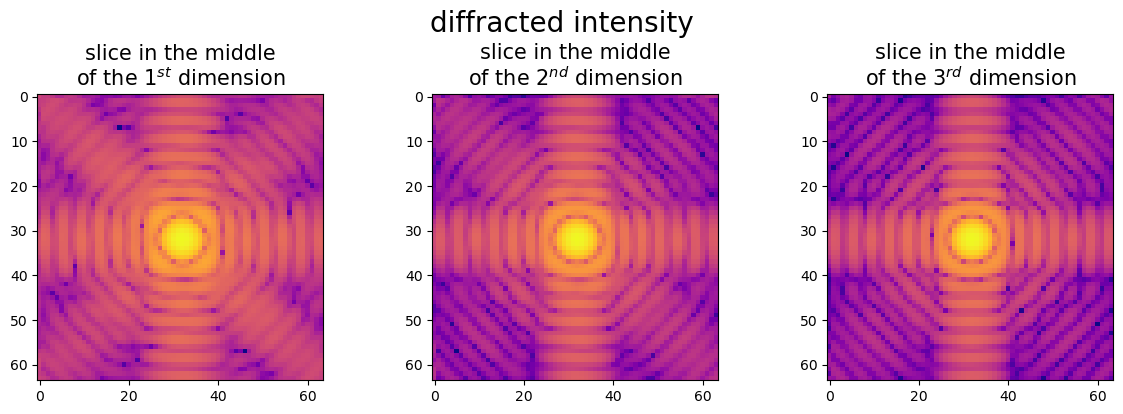

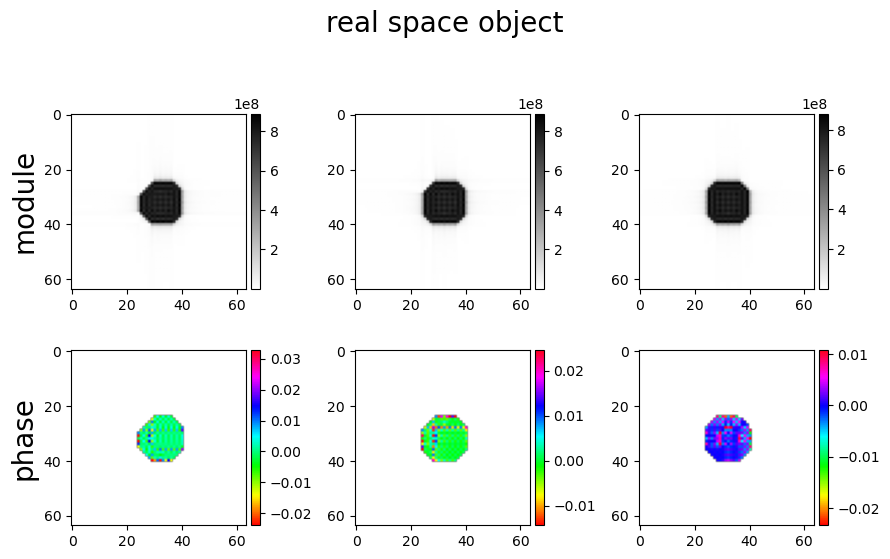

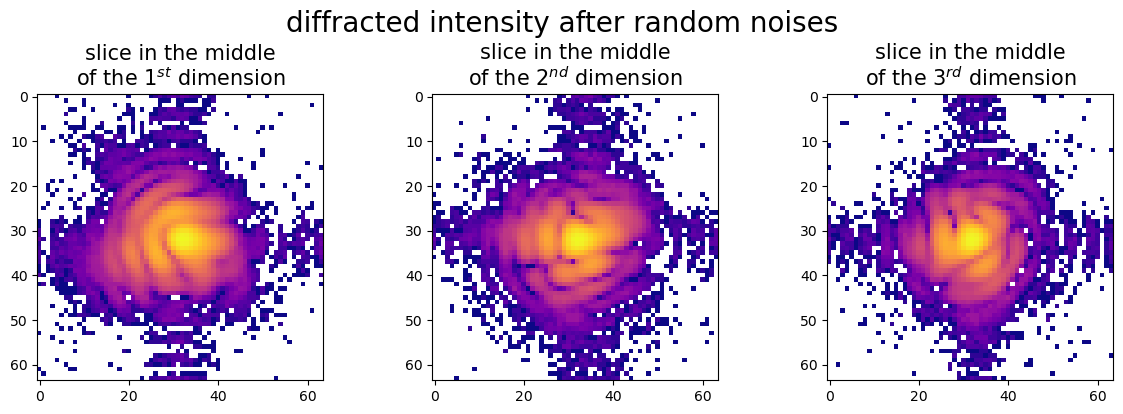

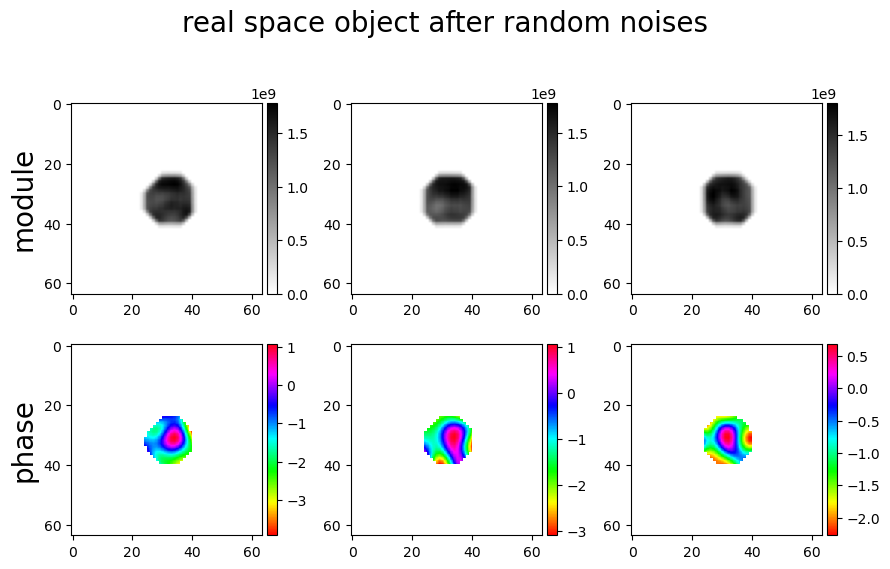

In [6]:
filename = 'particle.lmp'
x,y,z = read_lmp(filename)

# We use lattice parameters from the litterature for the atomic elements of our particle
lattice_dict = {'Au':4.080, 'Ag':4.090, 'Al':4.050, 'Pt': 3.9201}

# Select the Bragg reflection
hkl = [1, 1, 1]

# Some parameters for the 3D grid in reciprocal space

sizeQ = 64 # Size of the 3D matrix. Here 64x64x64

nstep = np.random.randint(80,160) # step in reciprocal space. Random for more diversity in the dataset.
                                   
element = 'Au' # atomic element of our particle
lattice = lattice_dict[element] # lattice parameter of the particle
dq = 1/lattice/nstep # step size in reciprocal space
random_rotation = False  # make a random rotation of the q space (equivalent to a rotation of the particle)
random_shift = False # Not sure if this is really useful in the end
center_the_center_of_mass = False # Put it to True if you want to recenter the diffraction

# Create the 3D grid
qx,qy,qz = Createqxqyqz(dq,sizeQ,hkl,element,
                        random_rotation=random_rotation,
                       random_shift=random_shift)

# Create the 3D matrix of diffraction
Fexp = Create_diffraction(qx,qy,qz,x,y,z,hkl,element,
                      center_the_center_of_mass=center_the_center_of_mass)
I = np.abs(Fexp)**2.

obj = ifftshift(fftn(fftshift(Fexp)))


# Add different complex phase to the object + Poisson noise to the diffraction pattern
obj_centered = center_object(obj)

strain = np.random.choice(['random', 'gauss', 'cosine'])
phase_range1 = np.random.uniform(5,18)
phase_range2 = np.random.uniform(5,18)
sigma1 = np.random.uniform(100,800)
sigma2 = np.random.uniform(100,800)
scale = 5

I,phi = add_random_noise(obj_centered, 
             strain = 'random',
             corr_phase = None,
             phase_range1 = phase_range1,
             phase_range2 = phase_range2, 
             sigma1 = sigma1, 
             sigma2 = sigma2, 
             poisson_noise = True,
             scale_poisson = 10**(scale),  
             plot=True)

obje_noise = ifftshift(ifftn(fftshift(np.sqrt(I)*np.exp(1.0j*phi))))
